# 📧 Email Spam Detection with Machine Learning

## Objective

The objective of this project is to build a machine learning model that classifies SMS messages as **Spam** or **Ham (Not Spam)** using Natural Language Processing (NLP) techniques.

The project includes text preprocessing, TF-IDF feature extraction, model training, evaluation, and comparison of multiple classification algorithms.

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Preprocessing
import re
import nltk
from nltk.corpus import stopwords

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Save Model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dhars\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
df = pd.read_csv("../dataset/spam.csv")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

In [8]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (5572, 5)


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [10]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [11]:
df = df[['v1', 'v2']]

df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 403


In [14]:
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (5169, 2)


In [15]:
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

In [16]:
(df['label'].value_counts(normalize=True) * 100).round(2)

label
ham     87.37
spam    12.63
Name: proportion, dtype: float64

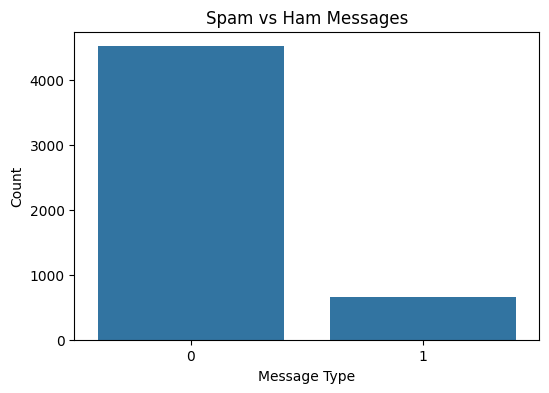

In [47]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='label')

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.savefig(
    "../images/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- The dataset contains two classes: **Ham** and **Spam**.
- Ham messages are significantly more common than spam messages.
- This indicates that the dataset is **imbalanced**, which is a common characteristic of real-world spam detection datasets.

## Text Preprocessing

Text preprocessing is an essential step in Natural Language Processing (NLP). It converts raw text into a clean format suitable for machine learning models.

The preprocessing steps include:
- Converting text to lowercase
- Removing punctuation and special characters
- Removing stopwords (common words like "the", "is", "and")

In [18]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dhars\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
def clean_text(text):
    
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation, numbers and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    # Join words back into a sentence
    return " ".join(words)

In [20]:
df['clean_message'] = df['message'].apply(clean_text)

df.head()

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [21]:
comparison = pd.DataFrame({
    'Original Message': df['message'].head(5),
    'Cleaned Message': df['clean_message'].head(5)
})

comparison

,Original Message,Cleaned Message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


### Observation

After preprocessing:

- All messages have been converted to lowercase.
- Numbers, punctuation, and special characters have been removed.
- Common stopwords have been removed.
- The cleaned text is more suitable for machine learning algorithms.

## TF-IDF (Term Frequency - Inverse Document Frequency)

TF-IDF is a numerical technique used to convert text into machine-readable features.

- **Term Frequency (TF):** Measures how frequently a word appears in a document.
- **Inverse Document Frequency (IDF):** Reduces the importance of words that appear frequently across many documents.

TF-IDF assigns higher weights to words that are important in a particular message while reducing the influence of common words. This makes it an effective feature extraction technique for text classification tasks such as spam detection.

In [22]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [23]:
X = df['clean_message']
y = df['label']

In [24]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(X)

In [25]:
print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (5169, 5000)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 4135
Testing Samples  : 1034


### Observation

The dataset has been divided into:

- **80% Training Data** for training the machine learning models.
- **20% Testing Data** for evaluating model performance.

This helps assess how well the models generalize to unseen data.

In [27]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [28]:
nb_predictions = nb_model.predict(X_test)

In [29]:
print("Multinomial Naive Bayes Performance")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, nb_predictions))
print("Precision:", precision_score(y_test, nb_predictions))
print("Recall   :", recall_score(y_test, nb_predictions))
print("F1 Score :", f1_score(y_test, nb_predictions))

Multinomial Naive Bayes Performance
----------------------------------------
Accuracy : 0.9690522243713733
Precision: 1.0
Recall   : 0.7793103448275862
F1 Score : 0.875968992248062


In [30]:
print(classification_report(y_test, nb_predictions))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       1.00      0.78      0.88       145

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



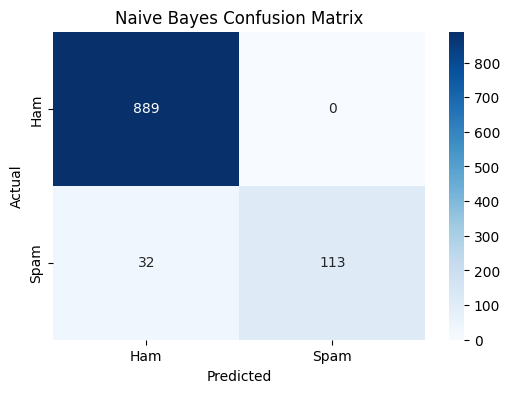

In [46]:
cm = confusion_matrix(y_test, nb_predictions)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham','Spam'],
    yticklabels=['Ham','Spam']
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(
    "../images/naive_bayes_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
lr_predictions = lr_model.predict(X_test)

In [34]:
print("Logistic Regression Performance")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, lr_predictions))
print("Precision:", precision_score(y_test, lr_predictions))
print("Recall   :", recall_score(y_test, lr_predictions))
print("F1 Score :", f1_score(y_test, lr_predictions))

Logistic Regression Performance
----------------------------------------
Accuracy : 0.9497098646034816
Precision: 0.9345794392523364
Recall   : 0.6896551724137931
F1 Score : 0.7936507936507936


In [35]:
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       889
           1       0.93      0.69      0.79       145

    accuracy                           0.95      1034
   macro avg       0.94      0.84      0.88      1034
weighted avg       0.95      0.95      0.95      1034



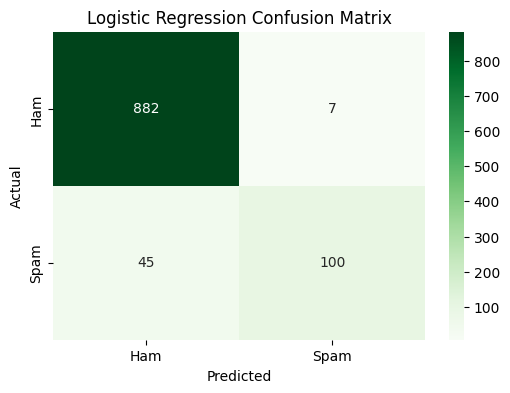

In [45]:
cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Ham','Spam'],
    yticklabels=['Ham','Spam']
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(
    "../images/logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [37]:
comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, nb_predictions),
        accuracy_score(y_test, lr_predictions)
    ],
    "Precision": [
        precision_score(y_test, nb_predictions),
        precision_score(y_test, lr_predictions)
    ],
    "Recall": [
        recall_score(y_test, nb_predictions),
        recall_score(y_test, lr_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, nb_predictions),
        f1_score(y_test, lr_predictions)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.969052,1.000000,0.779310,0.875969
1,Logistic Regression,0.949710,0.934579,0.689655,0.793651


In [38]:
best_model = lr_model if accuracy_score(y_test, lr_predictions) >= accuracy_score(y_test, nb_predictions) else nb_model

print("Best Model Selected:")
print(type(best_model).__name__)

Best Model Selected:
MultinomialNB


In [39]:
joblib.dump(best_model, "../models/spam_detection_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


## Why is Recall Important in Spam Detection?

Recall measures the ability of the model to correctly identify spam messages.

A high recall ensures that most spam messages are detected and prevented from reaching the user's inbox. Missing spam messages can expose users to phishing attacks, scams, and unwanted advertisements.

Therefore, recall is an important evaluation metric for spam detection systems.

In [40]:
from wordcloud import WordCloud

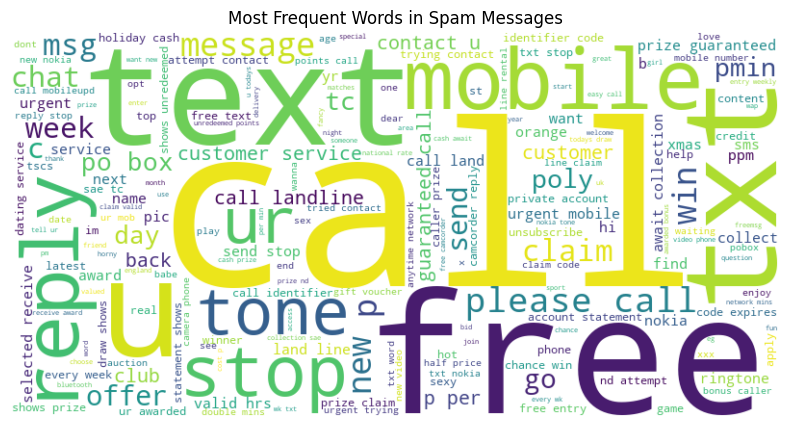

In [43]:
spam_words = " ".join(df[df['label'] == 1]['clean_message'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Spam Messages")
plt.savefig(
    "../images/spam_wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

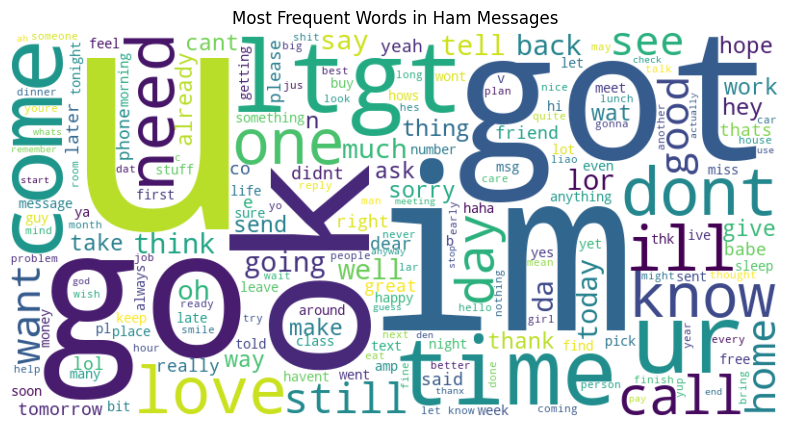

In [44]:
ham_words = " ".join(df[df['label'] == 0]['clean_message'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(ham_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Ham Messages")
plt.savefig(
    "../images/ham_wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()